# Implement LTS (2022 version)

This notebook implements the [Level of Traffic Stress](https://peterfurth.sites.northeastern.edu/2014/05/21/criteria-for-level-of-traffic-stress/) model. Specifically, the [2022 edition](https://bpb-us-e1.wpmucdn.com/sites.northeastern.edu/dist/e/618/files/2014/05/LTS-Tables-v2.2.pdf) though there is more background in the [original model](https://peterfurth.sites.northeastern.edu/level-of-traffic-stress/).

In short, this quantifies how stressful or comfortable a road is to bike on.
* Level 1: Cyclists are not in contact with traffic (except for slow, low volume traffic); comfortable for all level of cycling abilities (including children).
* Level 2: Cyclists have their own space and intersections are easy to navigate; comfortable for adult cyclists.
* Level 3: Cyclists interact with some moderate/multi-lane traffic or close to higher-speed traffic; acceptable for 'enthused and confident' cyclists.
* Level 4: Cyclists interact with or are near high-speed traffic; acceptable for 'strong and fearless' cyclists.

The first step was find correspondence between the descriptions and the available [DC road data](https://opendata.dc.gov/datasets/DCGIS::roadway-block/about). This is summarized in the table below.

| [Method](https://bpb-us-e1.wpmucdn.com/sites.northeastern.edu/dist/e/618/files/2014/05/LTS-Tables-v2.2.pdf)                                                                                                                                               | [Data](https://opendata.dc.gov/datasets/DCGIS::roadway-block/about)                                                                                                                                                                                 |
| ---------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Bike lane type (bikes in mixed traffic)                                                                                                              | TOTALBIKELANES (if it’s zero, then it’s mixed traffic)                                                                                                                                                                                              |
| Bike lane type (conventional; buffered considered conventional with buffer width considered part of lane width; also mentions advisory and shoulder) | BIKELANE_CONVENTIONAL, BIKELANE_BUFFERED                                                                                                                                                                                                            |
| Bike lane (separate from traffic)                                                                                                                    | BIKELANE_DUAL_PROTECTED, BIKELANE_PROTECTED                                                                                                                                                                                                         |
| Bike lane (conventional, advisory, shoulder) adjacency to parking lane                                                                               | BIKELANE_PARKINGLANE_ADJACENT                                                                                                                                                                                                                       |
| Bike lane width                                                                                                                                      | TOTALBIKELANEWIDTH (no direct way of getting buffer width so subtract all individual elements from total cross width, assuming the leftover difference is the bike lane buffer) divide by TOTALBIKELANES (substitute for not having width-per-lane) |
| Is bike lane frequently blocked?                                                                                                                     | No equivalent (might be worth surveying users)                                                                                                                                                                                                      |
| Is bike lane next to curb, road edge, or discontinuous?                                                                                              | No equivalent                                                                                                                                                                                                                                       |
| Centerline                                                                                                                                           | No direct comparison (using DOUBLEYELLOW_LINE and TOTALRAISEDBUFFERS)                                                                                                                                                                               |
| Number of trave lanes in each direction (not always clear what to do if there is, say, 1 lane in one direction and 2 in the other)                   | TOTALTRAVELLANES, TOTALTRAVELLANESINBOUND, TOTALTRAVELLANESOUTBOUND (other lane types include: TOTALTRAVELLANESBIDIRECTIONAL and TOTALTRAVELLANESREVERSIBLE)                                                                                        |
| Road width                                                                                                                                           | TOTALCROSSSECTIONWIDTH                                                                                                                                                                                                                              |
| Parking lane (none, one side, both sides)                                                                                                            | TOTALPARKINGLANES (doesn’t specify which side of road but number of lanes is probably a fairly good proxy)                                                                                                                                          |
| ADT (average daily traffic)                                                                                                                          | AADT                                                                                                                                                                                                                                                |
| Prevailing traffic speed                                                                                                                             | Closest we can get is speedlimit (SPEEDLIMITS_OB)                                                                                                                                                                                                   |


The tables have been translated into 'LTS.xlsx'

In [1]:
import requests
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns

## Get road data from DC website

In [2]:
# 2) Get Roadblock data from website
CRS = 'EPSG:4326'
def try_fetch_dc_roads():
    url = "https://opendata.arcgis.com/datasets/DCGIS::roadway-block.geojson"
    try:
        print('trying website')
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        print(r)
        print(url)
        if r.ok:
            gj = r.json()
            roads = gpd.GeoDataFrame.from_features(gj["features"], crs=CRS)
            return roads
    except Exception as error:
        print('Error reading road data from dc gov website')

roads = try_fetch_dc_roads()
roads['index'] = roads.index
roads = roads.drop(columns='geometry')
roads.to_csv('Roadway_Block_downloaded.csv')
roads

trying website
<Response [200]>
https://opendata.arcgis.com/datasets/DCGIS::roadway-block.geojson


,ROUTEID,FROMMEASURE,TOMEASURE,ROUTENAME,ROADTYPE,BLOCKKEY,TOTALTRAVELLANES,TOTALPARKINGLANES,TOTALRAISEDBUFFERS,TOTALTRAVELLANEWIDTH,...,AADT_COMBINATION,AADT_COMBINATION_YEAR,AADT_SINGLE_UNIT,AADT_SINGLE_UNIT_YEAR,DC_MAINTENANCE_OPERATIONS,MAINTENANCE_OPERATIONS,VERTICAL_DEFLECTION,OBJECTID,SHAPELEN,index
0,11000602,1276.872559,1341.946655,6TH ST NW,1,4af7e25abf59911305f2724cadc85a08,4,2,0,37,...,118.0,2020.0,254.0,2020.0,1,1,NaN,4195027,0,0
1,11003202,1903.893433,2010.185181,32ND ST NW,1,5b3f1964647d6c0b30c8189fd594208c,2,2,0,16,...,NaN,NaN,NaN,NaN,1,1,NaN,4195028,0,1
2,11037892,2905.775879,3044.950439,FOXHALL RD NW,1,fb2d4a22a88f8d4a7566a28b49aee1f9,2,0,0,24,...,32.0,2020.0,435.0,2020.0,1,1,NaN,4195029,0,2
3,11001602,7297.375977,7377.106445,16TH ST NW,1,a9903cf6a4ade86eb26343cd52cf1ffb,4,0,1,40,...,312.0,2020.0,1443.0,2020.0,1,1,NaN,4195030,0,3
4,11033472,595.138123,774.214478,EMERSON ST NW,1,4cfb9ba5eb597b707b798513462ef851,2,2,0,16,...,NaN,NaN,NaN,NaN,1,1,YES,4195031,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13833,13081512,1708.880371,1905.117065,SOUTHERN AVE SE,1,03ceb30917e33f51246b9427451bf29a,4,0,0,42,...,111.0,2020.0,736.0,2020.0,1,1,NaN,4211500,0,13833
13834,13064282,1059.627930,1160.749512,NEW JERSEY AVE SE,1,f8c1e5fae8a0321753beea69ef9d88f1,2,2,0,20,...,NaN,NaN,NaN,NaN,1,1,NaN,4211501,0,13834
13835,13018522,134.191696,248.385300,BRUCE PL SE,1,6e06a429de20637fc25ec5ee5bdad443,2,2,0,18,...,NaN,NaN,NaN,NaN,1,1,NaN,4211502,0,13835
13836,13076442,0.000000,51.074902,ROBINSON PL SE,1,a476aa40bc64479559e7361d9c105d16,2,0,0,28,...,NaN,NaN,NaN,NaN,1,1,NaN,4211503,0,13836


In [3]:
# read in file if it's already saved
#roads = pd.read_csv('Roadway_Block_downloaded.csv')

## Make additional columns (PERBIKELANEWIDTH, ADJPLREACH)

* PERBIKELANEWIDTH: Model needs bike lane with to include buffer width but there is no column for this so test if width of conventional lanes is less than buffered lanes. It is so, so find un-accounted for width of roads with buffered bike lanes and add that to bike lane width (so just divide by number of bike lanes).
* ADJPRLREACH: adjacent to parking lane reach (includes bike width and parking lane width), should be per-lane (so just divide by number of bike lanes)

### PERBIKELANEWIDTH

number of buffered lanes: 185
number of just buffered lanes: 119
mean width: 5.436974789915967
avg_width
5.0    68
6.0    24
8.0    10
4.0     7
7.0     3
4.5     3
6.5     2
2.0     1
5.5     1
Name: count, dtype: int64
leftover_width
3     21
4     19
7     18
2     14
11     9
5      6
6      5
16     4
21     3
13     3
12     2
14     2
10     2
18     2
17     2
8      2
9      2
19     1
27     1
15     1
Name: count, dtype: int64


<Axes: >

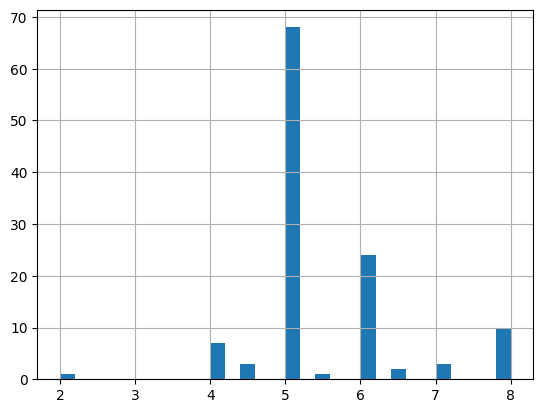

In [4]:
print('number of buffered lanes: '+str(len(roads[~roads['BIKELANE_BUFFERED'].isna()])))
print('number of just buffered lanes: '+str(len(roads[(~roads['BIKELANE_BUFFERED'].isna()) & (roads['BIKELANE_CONTRAFLOW'].isna()) & (roads['BIKELANE_CONVENTIONAL'].isna()) & (roads['BIKELANE_DUAL_PROTECTED'].isna()) & (roads['BIKELANE_PROTECTED'].isna())])))
roads_buffered = roads[(~roads['BIKELANE_BUFFERED'].isna()) & (roads['BIKELANE_CONTRAFLOW'].isna()) & (roads['BIKELANE_CONVENTIONAL'].isna()) & (roads['BIKELANE_DUAL_PROTECTED'].isna()) & (roads['BIKELANE_PROTECTED'].isna())]
roads_buffered = roads_buffered[['BIKELANE_CONTRAFLOW', 'BIKELANE_CONVENTIONAL', 'BIKELANE_DUAL_PROTECTED', 'BIKELANE_PROTECTED', 'BIKELANE_BUFFERED', 'TOTALBIKELANES', 'TOTALBIKELANEWIDTH', 'TOTALTRAVELLANEWIDTH', 'TOTALCROSSSECTIONWIDTH', 'TOTALPARKINGLANEWIDTH', 'TOTALRAISEDBUFFERWIDTH']]
roads_buffered['avg_width'] = roads_buffered['TOTALBIKELANEWIDTH']/roads_buffered['TOTALBIKELANES']
roads_buffered['leftover_width'] = roads_buffered['TOTALCROSSSECTIONWIDTH']-roads_buffered['TOTALTRAVELLANEWIDTH']-roads_buffered['TOTALPARKINGLANEWIDTH']-roads_buffered['TOTALRAISEDBUFFERWIDTH']-roads_buffered['TOTALBIKELANEWIDTH']
print('mean width: '+str(roads_buffered['avg_width'].mean()))
print(roads_buffered['avg_width'].value_counts())
print(roads_buffered['leftover_width'].value_counts())
roads_buffered['avg_width'].hist(bins = 30)

<Axes: >

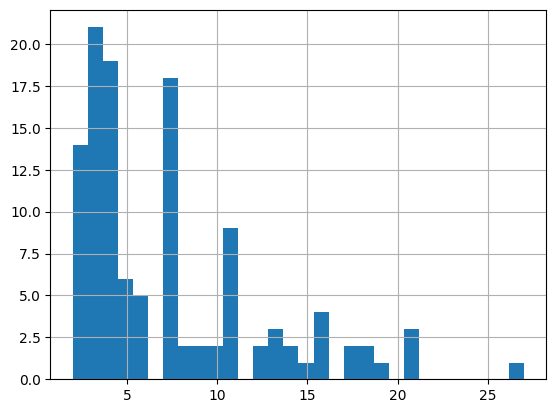

In [5]:
roads_buffered['leftover_width'].hist(bins = 30)

number of conventional lanes: 1046
number of just conventional lanes: 900
mean width: 5.038703703703703
avg_width
5.000000     827
6.000000      35
4.000000      21
5.500000       6
4.500000       3
3.000000       2
7.500000       2
4.333333       1
11.000000      1
16.000000      1
7.000000       1
Name: count, dtype: int64
leftover_width
0     463
1     406
3       5
8       4
2       4
5       4
6       4
10      3
4       2
9       2
16      1
12      1
14      1
Name: count, dtype: int64


<Axes: >

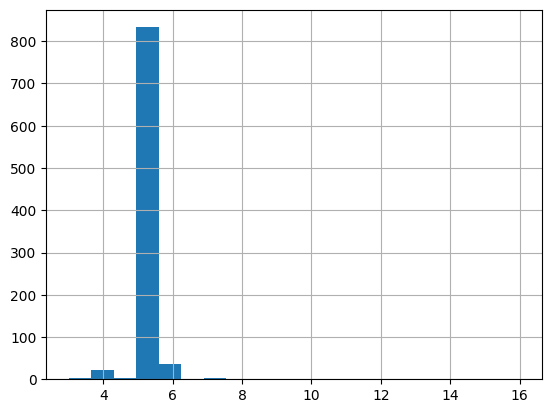

In [6]:
print('number of conventional lanes: '+str(len(roads[~roads['BIKELANE_CONVENTIONAL'].isna()])))
print('number of just conventional lanes: '+str(len(roads[(roads['BIKELANE_BUFFERED'].isna()) & (roads['BIKELANE_CONTRAFLOW'].isna()) & (~roads['BIKELANE_CONVENTIONAL'].isna()) & (roads['BIKELANE_DUAL_PROTECTED'].isna()) & (roads['BIKELANE_PROTECTED'].isna())])))
roads_conv = roads[(roads['BIKELANE_BUFFERED'].isna()) & (roads['BIKELANE_CONTRAFLOW'].isna()) & (~roads['BIKELANE_CONVENTIONAL'].isna()) & (roads['BIKELANE_DUAL_PROTECTED'].isna()) & (roads['BIKELANE_PROTECTED'].isna())]
roads_conv = roads_conv[['BIKELANE_CONTRAFLOW', 'BIKELANE_CONVENTIONAL', 'BIKELANE_DUAL_PROTECTED', 'BIKELANE_PROTECTED', 'BIKELANE_BUFFERED', 'TOTALBIKELANES', 'TOTALBIKELANEWIDTH', 'TOTALTRAVELLANEWIDTH', 'TOTALCROSSSECTIONWIDTH', 'TOTALPARKINGLANEWIDTH', 'TOTALRAISEDBUFFERWIDTH']]
roads_conv['avg_width'] = roads_conv['TOTALBIKELANEWIDTH']/roads_conv['TOTALBIKELANES']
roads_conv['leftover_width'] = roads_conv['TOTALCROSSSECTIONWIDTH']-roads_conv['TOTALTRAVELLANEWIDTH']-roads_conv['TOTALPARKINGLANEWIDTH']-roads_conv['TOTALRAISEDBUFFERWIDTH']-roads_conv['TOTALBIKELANEWIDTH']
print('mean width: '+str(roads_conv['avg_width'].mean()))
print(roads_conv['avg_width'].value_counts())
print(roads_conv['leftover_width'].value_counts())
roads_conv['avg_width'].hist(bins = 20)

<Axes: >

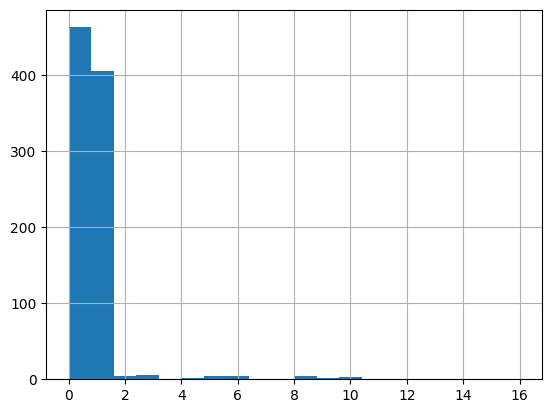

In [7]:
roads_conv['leftover_width'].hist(bins = 20)

Looks like un-accounted for space in cross section is likely buffer. So let's create a 'total bikelane width' column. It if there is a buffered bike lane, it will include the unaccounted for space. If there isn't, it'll just be the total bikelane width. Also create a per-lane width as well. (just divide total width by number of bike lanes)

This will not account for different bike lane types.

In [8]:
roads['TOTALBIKELANEWIDTH_WEXTRA'] = 0.0
roads['PERBIKELANEWIDTH'] = 0.0
buffered_ind = ~roads['BIKELANE_BUFFERED'].isna()
roads.loc[buffered_ind, 'TOTALBIKELANEWIDTH_WEXTRA'] = roads['TOTALCROSSSECTIONWIDTH'][buffered_ind]-roads['TOTALTRAVELLANEWIDTH'][buffered_ind]-roads['TOTALPARKINGLANEWIDTH']-roads['TOTALRAISEDBUFFERWIDTH']
lane_not_buffered_ind = roads['BIKELANE_BUFFERED'].isna() & ~roads['BIKELANE_CONVENTIONAL'].isna()
roads.loc[lane_not_buffered_ind, 'TOTALBIKELANEWIDTH_WEXTRA'] = roads['TOTALBIKELANEWIDTH'][lane_not_buffered_ind]
lane_ind = buffered_ind | lane_not_buffered_ind
roads.loc[lane_ind, 'PERBIKELANEWIDTH'] = roads['TOTALBIKELANEWIDTH_WEXTRA'][lane_ind]/roads['TOTALBIKELANES'][lane_ind]
roads

,ROUTEID,FROMMEASURE,TOMEASURE,ROUTENAME,ROADTYPE,BLOCKKEY,TOTALTRAVELLANES,TOTALPARKINGLANES,TOTALRAISEDBUFFERS,TOTALTRAVELLANEWIDTH,...,AADT_SINGLE_UNIT,AADT_SINGLE_UNIT_YEAR,DC_MAINTENANCE_OPERATIONS,MAINTENANCE_OPERATIONS,VERTICAL_DEFLECTION,OBJECTID,SHAPELEN,index,TOTALBIKELANEWIDTH_WEXTRA,PERBIKELANEWIDTH
0,11000602,1276.872559,1341.946655,6TH ST NW,1,4af7e25abf59911305f2724cadc85a08,4,2,0,37,...,254.0,2020.0,1,1,NaN,4195027,0,0,0.0,0.0
1,11003202,1903.893433,2010.185181,32ND ST NW,1,5b3f1964647d6c0b30c8189fd594208c,2,2,0,16,...,NaN,NaN,1,1,NaN,4195028,0,1,0.0,0.0
2,11037892,2905.775879,3044.950439,FOXHALL RD NW,1,fb2d4a22a88f8d4a7566a28b49aee1f9,2,0,0,24,...,435.0,2020.0,1,1,NaN,4195029,0,2,0.0,0.0
3,11001602,7297.375977,7377.106445,16TH ST NW,1,a9903cf6a4ade86eb26343cd52cf1ffb,4,0,1,40,...,1443.0,2020.0,1,1,NaN,4195030,0,3,0.0,0.0
4,11033472,595.138123,774.214478,EMERSON ST NW,1,4cfb9ba5eb597b707b798513462ef851,2,2,0,16,...,NaN,NaN,1,1,YES,4195031,0,4,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13833,13081512,1708.880371,1905.117065,SOUTHERN AVE SE,1,03ceb30917e33f51246b9427451bf29a,4,0,0,42,...,736.0,2020.0,1,1,NaN,4211500,0,13833,0.0,0.0
13834,13064282,1059.627930,1160.749512,NEW JERSEY AVE SE,1,f8c1e5fae8a0321753beea69ef9d88f1,2,2,0,20,...,NaN,NaN,1,1,NaN,4211501,0,13834,10.0,5.0
13835,13018522,134.191696,248.385300,BRUCE PL SE,1,6e06a429de20637fc25ec5ee5bdad443,2,2,0,18,...,NaN,NaN,1,1,NaN,4211502,0,13835,0.0,0.0
13836,13076442,0.000000,51.074902,ROBINSON PL SE,1,a476aa40bc64479559e7361d9c105d16,2,0,0,28,...,NaN,NaN,1,1,NaN,4211503,0,13836,0.0,0.0


In [9]:
roads[buffered_ind][['TOTALBIKELANES','BIKELANE_CONVENTIONAL','BIKELANE_BUFFERED', 'TOTALBIKELANEWIDTH', 'TOTALBIKELANEWIDTH_WEXTRA', 'PERBIKELANEWIDTH']]

,TOTALBIKELANES,BIKELANE_CONVENTIONAL,BIKELANE_BUFFERED,TOTALBIKELANEWIDTH,TOTALBIKELANEWIDTH_WEXTRA,PERBIKELANEWIDTH
22,2,NaN,BD,10,17.0,8.5
135,2,IB,OB,10,20.0,10.0
136,1,NaN,OB,5,9.0,9.0
195,1,NaN,IB,6,9.0,9.0
269,1,NaN,OB,5,17.0,17.0
...,...,...,...,...,...,...
13627,1,NaN,OB,8,11.0,11.0
13700,2,OB,IB,10,14.0,7.0
13759,2,OB,IB,10,12.0,6.0
13795,1,NaN,OB,8,11.0,11.0


In [10]:
roads[~roads['BIKELANE_CONVENTIONAL'].isna()][['TOTALBIKELANES','BIKELANE_CONVENTIONAL','BIKELANE_BUFFERED', 'TOTALBIKELANEWIDTH', 'TOTALBIKELANEWIDTH_WEXTRA', 'PERBIKELANEWIDTH']]

,TOTALBIKELANES,BIKELANE_CONVENTIONAL,BIKELANE_BUFFERED,TOTALBIKELANEWIDTH,TOTALBIKELANEWIDTH_WEXTRA,PERBIKELANEWIDTH
24,1,OB,NaN,5,5.0,5.0
31,1,OB,NaN,5,5.0,5.0
43,1,OB,NaN,5,5.0,5.0
58,2,BD,NaN,10,10.0,5.0
64,1,IB,NaN,5,5.0,5.0
...,...,...,...,...,...,...
13773,1,IB,NaN,5,5.0,5.0
13780,2,BD,NaN,10,10.0,5.0
13787,2,IB,NaN,10,10.0,5.0
13811,2,BD,NaN,10,10.0,5.0


### ADJPRLREACH

In [11]:
roads['ADJPLREACH'] = 0.0
adjPLReach_ind = ((~roads['BIKELANE_CONVENTIONAL'].isna()) | (~roads['BIKELANE_BUFFERED'].isna())) & (~roads['BIKELANE_PARKINGLANE_ADJACENT'].isna())
roads.loc[adjPLReach_ind, 'ADJPLREACH'] = roads[adjPLReach_ind]['PERBIKELANEWIDTH'] + roads[adjPLReach_ind]['TOTALPARKINGLANEWIDTH']/roads[adjPLReach_ind]['TOTALPARKINGLANES']
roads[adjPLReach_ind]

,ROUTEID,FROMMEASURE,TOMEASURE,ROUTENAME,ROADTYPE,BLOCKKEY,TOTALTRAVELLANES,TOTALPARKINGLANES,TOTALRAISEDBUFFERS,TOTALTRAVELLANEWIDTH,...,AADT_SINGLE_UNIT_YEAR,DC_MAINTENANCE_OPERATIONS,MAINTENANCE_OPERATIONS,VERTICAL_DEFLECTION,OBJECTID,SHAPELEN,index,TOTALBIKELANEWIDTH_WEXTRA,PERBIKELANEWIDTH,ADJPLREACH
24,11000802,6026.136230,6210.016113,8TH ST NW,1,7028022eb2ddc14b56a7d5e090c89961,1,2,0,10,...,NaN,1,1,YES,4195051,0,24,5.0,5.0,12.5
31,11001202,764.513489,872.439026,12TH ST NW,1,a0c7260c3824e5d98a8272a0dea47197,2,2,0,20,...,NaN,1,1,NaN,4195058,0,31,5.0,5.0,14.0
43,11064412,769.510315,792.968201,NEW MEXICO AVE NW,1,5cce0fd3e2d6d45f5b7bbdeac883f3a0,2,2,0,20,...,2020.0,1,1,NaN,4195070,0,43,5.0,5.0,13.0
58,11000702,2102.751709,2221.992432,7TH ST NW,1,186de2ca1ec920117b3a3c3efed0380f,2,2,0,22,...,2020.0,1,1,NaN,4195085,0,58,10.0,5.0,13.0
64,11033862,1641.014160,1702.536743,EUCLID ST NW,1,2f7e6a2a12583aecba70dc3e18550bf3,1,2,0,10,...,NaN,1,1,NaN,4195091,0,64,5.0,5.0,12.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13759,13034462,154.392395,225.167496,EAST CAPITOL ST SE,1,6f386fee838ed54d564cf493c0808a8b,2,2,0,20,...,NaN,1,1,NaN,4211426,0,13759,12.0,6.0,14.0
13773,13001402,125.595001,210.844299,14TH ST SE,1,51cbaeebbf932bd5a35ae70d28dc1820,1,2,0,8,...,NaN,1,1,NaN,4211440,0,13773,5.0,5.0,13.0
13780,13031332,481.594086,610.044189,E ST SE,1,2d375e469680fbc169c6e912f9fba3a0,2,2,0,20,...,NaN,1,1,NaN,4211447,0,13780,10.0,5.0,13.0
13811,13000102,1383.720337,1480.840332,1ST ST SE,1,fb2d00801282fe317232b851a2aa2532,4,2,0,44,...,NaN,1,1,NaN,4211478,0,13811,10.0,5.0,13.0


In [12]:
#for c in roads.columns:
#    print(c)

### Helper functions

In [13]:
#set speedlimit with min and max speedlimit to take the more human-readable version of the table and make it more machine-readable   
def is_float(element):
    try:
        float(element)
        return True
    except ValueError:
        return False
        
def level_rules(df):
    #get speedlimit
    max_speedlimit = [x for x in df.columns if is_float(x)]
    non_speedlimit = [x for x in df.columns if not is_float(x)]

    # Build lower bounds for each speedlimit bin
    min_speedlimit = [0.0] + max_speedlimit[:-1]

    # Reshape dataframe
    df = (
        df.set_index(non_speedlimit)
          .stack(future_stack=True)
          .rename_axis(index={None: 'maxspeed'})
          .reset_index(name='level')
    )

    # Add minimum speed column
    df['minspeed'] = df['maxspeed'].apply(
        lambda x: min_speedlimit[max_speedlimit.index(x)]
    )
    
    # Swap last two columns
    cols = list(df.columns)
    cols[-1], cols[-2] = cols[-2], cols[-1]

    df = df[cols]
    return df

In [43]:
# This function goes through each ADT, PERBIKELANEWIDTH, or ADJPLREACH and speedlimit option for the general criteria outlined in the next section.
# Given the general criteria, the limiting factor, and speelimit, the LTS is assigned to any road segment matching all the necessary elements

def get_levels(
    curr_df,
    curr_roads,
    road_levels,
    value_col=None,
    min_col=None,
    max_col=None,
    ignore_value=False,
    handle_nan_value=False,
    assign_leftovers=False,
    assign_no_speed=True,
):
    print(len(curr_roads))
    print('-----')
    for _, row in curr_df.iterrows():
        print(f"{row.get(min_col, 'NA')} --- {row['minspeed']}")

        # Base speed filter
        mask = ((curr_roads['SPEEDLIMITS_OB'] >= row['minspeed']) & (curr_roads['SPEEDLIMITS_OB'] < row['maxspeed']))

        #some general criteria don't break down by ADT, just by speedlimit
        if not ignore_value and value_col is not None:
            if handle_nan_value and pd.isna(row[max_col]):
                mask &= curr_roads[value_col].isna()
            else:
                mask &= ((curr_roads[value_col] >= row[min_col]) & (curr_roads[value_col] < row[max_col]))
        sel = curr_roads[mask]
        print(len(sel))
        # Assign levels
        road_levels.update(dict.fromkeys(sel['index'].values, row['level']))

    # Assign roads with missing speed limits
    if assign_no_speed:
        sel = curr_roads[curr_roads['SPEEDLIMITS_OB'].isna()]
        print('no speedlimit')
        print(len(sel))
        road_levels.update(dict.fromkeys(sel['index'].values, row['level']))

    # Assign leftover roads (better to air on the side of caution than saying a road is safer than it really is)
    if assign_leftovers:
        inds = np.setdiff1d(curr_roads['index'].values, list(road_levels.keys()))
        print('left over')
        print(len(inds))
        sel = curr_roads[curr_roads['index'].isin(inds)]
        road_levels.update(dict.fromkeys(sel['index'].values, row['level']))

    return road_levels

## Mixed roads

This scenario has the most complex logic. The general logic is based on the number of lanes (whether there is a centerline, if it's two-way, if it's wide, how many lanes there are), the average daily traffic (ADT), and prevailing speed. LTS.xlsx contains the logic to assign the level to the roads that fit each criteria.

### Variable equivalence

* to use this table: TOTALBIKELANES == 0
* Directionality: SUMMARYDIRECTION == BD or ?? is two way, IB or OB is one way, sometimes don't need to check
* centerline: DOUBLEYELLOW_LINE == yes or TOTALRAISEDBUFFERS > 0 (no centerline- DOUBLEYELLOW_LINE != yes and TOTALRAISEDBUFFERS == 0
* Total number of Travel Lanes: TOTALTRAVELLANES
* Number of travel lanes inbound: TOTALTRAVELLANESINBOUND
* Number of travel lanes outbound: TOTALTRAVELLANESOUTBOUND
* width_onewaynparking:  TOTALPARKINGLANES is 0,1, or 2/greater (doesn't mean it's on both sides), width: TOTALCROSSSECTIONWIDTH (threshold will depend on number of parking lanes
* min ADT and max ADT: AADT
* maxspeed and minspeed: SPEEDLIMITS_OB

### Set up mixed-traffic

In [68]:
file_path = 'LTS.xlsx' 
sheet_name = 'MixedTraffic' # Replace with the actual sheet name

# Read the specific sheet into a DataFrame
df_sheet = pd.read_excel(file_path, sheet_name=sheet_name)
df_sheet.head()

,Bike lane,Description,Directionality,centerline,Total number of Travel Lanes,Number of travel lanes in one direction,width_oneway,min ADT,max ADT,23.5,28.5,33.5,38.5,43.5,48.5,100
0,none,Unlaned 2-way street (no centerline),2.0,0.0,max2,NaN,NaN,0.0,750.0,1,1,2,2,3,3,3
1,none,Unlaned 2-way street (no centerline),2.0,0.0,max2,NaN,NaN,750.0,1500.0,1,1,2,3,3,3,3
2,none,Unlaned 2-way street (no centerline),2.0,0.0,max2,NaN,NaN,1500.0,3000.0,2,2,2,3,3,4,4
3,none,Unlaned 2-way street (no centerline),2.0,0.0,max2,NaN,NaN,3000.0,1000000.0,2,2,3,3,4,4,4
4,none,Unlaned 2-way street (no centerline),2.0,0.0,max2,NaN,NaN,NaN,NaN,2,2,2,3,3,4,4


In [69]:
df = level_rules(df_sheet)

In [70]:
#keep the roads with no bikelanes (bikes go in the car lane traffic)
roads_mixed = roads[roads['TOTALBIKELANES'] ==0]
roads_mixed

,ROUTEID,FROMMEASURE,TOMEASURE,ROUTENAME,ROADTYPE,BLOCKKEY,TOTALTRAVELLANES,TOTALPARKINGLANES,TOTALRAISEDBUFFERS,TOTALTRAVELLANEWIDTH,...,AADT_SINGLE_UNIT_YEAR,DC_MAINTENANCE_OPERATIONS,MAINTENANCE_OPERATIONS,VERTICAL_DEFLECTION,OBJECTID,SHAPELEN,index,TOTALBIKELANEWIDTH_WEXTRA,PERBIKELANEWIDTH,ADJPLREACH
0,11000602,1276.872559,1341.946655,6TH ST NW,1,4af7e25abf59911305f2724cadc85a08,4,2,0,37,...,2020.0,1,1,NaN,4195027,0,0,0.0,0.0,0.0
1,11003202,1903.893433,2010.185181,32ND ST NW,1,5b3f1964647d6c0b30c8189fd594208c,2,2,0,16,...,NaN,1,1,NaN,4195028,0,1,0.0,0.0,0.0
2,11037892,2905.775879,3044.950439,FOXHALL RD NW,1,fb2d4a22a88f8d4a7566a28b49aee1f9,2,0,0,24,...,2020.0,1,1,NaN,4195029,0,2,0.0,0.0,0.0
3,11001602,7297.375977,7377.106445,16TH ST NW,1,a9903cf6a4ade86eb26343cd52cf1ffb,4,0,1,40,...,2020.0,1,1,NaN,4195030,0,3,0.0,0.0,0.0
4,11033472,595.138123,774.214478,EMERSON ST NW,1,4cfb9ba5eb597b707b798513462ef851,2,2,0,16,...,NaN,1,1,YES,4195031,0,4,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13831,13005602,0.000000,75.672897,56TH ST SE,1,4f134473a059c441693e485dbec5a6c1,1,2,0,16,...,NaN,1,1,YES,4211498,0,13831,0.0,0.0,0.0
13833,13081512,1708.880371,1905.117065,SOUTHERN AVE SE,1,03ceb30917e33f51246b9427451bf29a,4,0,0,42,...,2020.0,1,1,NaN,4211500,0,13833,0.0,0.0,0.0
13835,13018522,134.191696,248.385300,BRUCE PL SE,1,6e06a429de20637fc25ec5ee5bdad443,2,2,0,18,...,NaN,1,1,NaN,4211502,0,13835,0.0,0.0,0.0
13836,13076442,0.000000,51.074902,ROBINSON PL SE,1,a476aa40bc64479559e7361d9c105d16,2,0,0,28,...,NaN,1,1,NaN,4211503,0,13836,0.0,0.0,0.0


In [72]:
#go through the different general criteria, then run get_levels to go through the ADT/speedlimit divisions
rules = [
    { #check directionality, centerline, and number of lanes (2,0,2)
        "name": "2lanes_no_center_bd",
        "road_mask": lambda r: (((r['SUMMARYDIRECTION'] == 'BD') | (r['SUMMARYDIRECTION'] == '??')) &
            (r['DOUBLEYELLOW_LINE'] != 'yes') & (r['TOTALRAISEDBUFFERS'] == 0) & (r['TOTALTRAVELLANES'] <= 2)),
        "df_mask": lambda d: ((d['Directionality'] == 2) & (d['centerline'] == 0) & (d['Total number of Travel Lanes'] == 'max2')),
        "ignore_value": False,
    },
    {#check directionality, centerline, and number of lanes in one direction (2,1,1perDir)
        "name": "2lanes_center_bd",
        "road_mask": lambda r: (
            ((r['SUMMARYDIRECTION'] == 'BD') | (r['SUMMARYDIRECTION'] == '??')) &
            ((r['DOUBLEYELLOW_LINE'] == 'yes') | (r['TOTALRAISEDBUFFERS'] > 0)) &
            (r['TOTALTRAVELLANESINBOUND'] == 1) & (r['TOTALTRAVELLANESOUTBOUND'] == 1)),
        "df_mask": lambda d: ((d['Directionality'] == 2) & (d['centerline'] == 1) &(d['Number of travel lanes in one direction'] == '1perDir')),
        "ignore_value": False,
    },
    {#check directionality and number of lanes (1, 1) and wide roads
        "name": "1lane_wide",
        "road_mask": lambda r: (((r['SUMMARYDIRECTION'] == 'IB') | (r['SUMMARYDIRECTION'] == 'OB')) & (r['TOTALTRAVELLANES'] == 1) &
            (
                ((r['TOTALPARKINGLANES'] == 0) & (r['TOTALCROSSSECTIONWIDTH'] >= 15)) |
                ((r['TOTALPARKINGLANES'] == 1) & (r['TOTALCROSSSECTIONWIDTH'] >= 22)) |
                ((r['TOTALPARKINGLANES'] > 1) & (r['TOTALCROSSSECTIONWIDTH'] >= 30))
            )
        ),
        "df_mask": lambda d: ((d['Directionality'] == 1) & (d['Total number of Travel Lanes'] == 1) & (d['width_oneway'] == 'wide')),
        "ignore_value": False,
    },
    {#check directionality and number of lanes (1, 1) and narrow roads
        "name": "1lane_narrow",
        "road_mask": lambda r: (((r['SUMMARYDIRECTION'] == 'IB') | (r['SUMMARYDIRECTION'] == 'OB')) &(r['TOTALTRAVELLANES'] == 1) &
            (
                ((r['TOTALPARKINGLANES'] == 0) & (r['TOTALCROSSSECTIONWIDTH'] < 15)) |
                ((r['TOTALPARKINGLANES'] == 1) & (r['TOTALCROSSSECTIONWIDTH'] < 22)) |
                ((r['TOTALPARKINGLANES'] > 1) & (r['TOTALCROSSSECTIONWIDTH'] < 30))
            )
        ),
        "df_mask": lambda d: ((d['Directionality'] == 1) & (d['Total number of Travel Lanes'] == 1) & (d['width_oneway'] == 'narrow')),
        "ignore_value": False,
    },
    {#check directionality (2) and 2 thru lanes in at least on direction
        "name": "max2",
        "road_mask": lambda r: (
            ((r['TOTALTRAVELLANESINBOUND'] == 2) & (r['TOTALTRAVELLANESOUTBOUND'] <= 2)) |
            ((r['TOTALTRAVELLANESOUTBOUND'] == 2) & (r['TOTALTRAVELLANESINBOUND'] <= 2))
        ),
        "df_mask": lambda d: (d['Number of travel lanes in one direction'] == 'max2'),
        "ignore_value": False,
    },
    {#check directionality (2) and 3 thru lanes in at leat least on direction
        "name": "min3",
        "road_mask": lambda r: ((r['TOTALTRAVELLANESINBOUND'] > 2) | (r['TOTALTRAVELLANESOUTBOUND'] > 2)),
        "df_mask": lambda d: ( (d['Number of travel lanes in one direction'] == 'min3')),
        "ignore_value": True,
    },
]

In [73]:
road_levels = {}

for rule in rules:

    print(rule["name"])

    curr_check = rule["road_mask"](roads_mixed)
    curr_roads = roads_mixed[curr_check]

    curr_df = df[rule["df_mask"](df)]

    print(len(curr_roads))

    road_levels = get_levels(curr_df, curr_roads, road_levels, value_col='AADT',
        min_col='min ADT', max_col='max ADT', ignore_value=rule["ignore_value"],
        handle_nan_value=True, assign_leftovers=True, assign_no_speed=True
    )

    print(len(road_levels))

2lanes_no_center_bd
8741
8741
-----
0.0 --- 0.0
8
0.0 --- 23.5
1
0.0 --- 28.5
0
0.0 --- 33.5
0
0.0 --- 38.5
0
0.0 --- 43.5
0
0.0 --- 48.5
0
750.0 --- 0.0
43
750.0 --- 23.5
30
750.0 --- 28.5
0
750.0 --- 33.5
0
750.0 --- 38.5
0
750.0 --- 43.5
0
750.0 --- 48.5
0
1500.0 --- 0.0
208
1500.0 --- 23.5
204
1500.0 --- 28.5
9
1500.0 --- 33.5
0
1500.0 --- 38.5
0
1500.0 --- 43.5
0
1500.0 --- 48.5
0
3000.0 --- 0.0
405
3000.0 --- 23.5
631
3000.0 --- 28.5
38
3000.0 --- 33.5
3
3000.0 --- 38.5
0
3000.0 --- 43.5
0
3000.0 --- 48.5
0
nan --- 0.0
6175
nan --- 23.5
519
nan --- 28.5
33
nan --- 33.5
1
nan --- 38.5
0
nan --- 43.5
0
nan --- 48.5
0
no speedlimit
433
left over
0
8741
2lanes_center_bd
92
92
-----
0.0 --- 0.0
1
0.0 --- 23.5
0
0.0 --- 28.5
0
0.0 --- 33.5
0
0.0 --- 38.5
0
0.0 --- 43.5
0
0.0 --- 48.5
0
1000.0 --- 0.0
0
1000.0 --- 23.5
0
1000.0 --- 28.5
0
1000.0 --- 33.5
0
1000.0 --- 38.5
0
1000.0 --- 43.5
0
1000.0 --- 48.5
0
1500.0 --- 0.0
12
1500.0 --- 23.5
21
1500.0 --- 28.5
2
1500.0 --- 33.5
0
1500.

# Conventional bike lane, not adjacent to a parking lane


The logic is based on the number of lanes, bike lane width, and prevailing speed. The bike lane width includes any buffer area. LTS.xlsx contains the logic to assign the level to the roads that fit each criteria.

## Variable equivalence

* Is the bike lane adjacent to a parking lane: BIKELANE_PARKINGLANE_ADJACENT
* bike lane: BIKELANE_CONTRAFLOW, BIKELANE_CONVENTIONAL, BIKELANE_BUFFERED
* BidirectionalLane: TOTALTRAVELLANESBIDIRECTIONAL (check if 0 or >0)
* Total number of Travel Lanes: TOTALTRAVELLANES
* Number of travel lanes in one direction: TOTALTRAVELLANESOUTBOUND and TOTALTRAVELLANESINBOUND
* max bike lane width and min bike lane width: PERBIKELANEWIDTH (might not be accurate)
* maxspeed and minspeed: SPEEDLIMITS_OB


In [74]:
file_path = 'LTS.xlsx' 
sheet_name = 'conventional_notPL' # Replace with the actual sheet name

# Read the specific sheet into a DataFrame
df_sheet = pd.read_excel(file_path, sheet_name=sheet_name)
df_sheet

,Bike lane,Frequent blocks,AdjacentToParking,BirectionalLane,Total number of Travel Lanes,Number of travel lanes in one direction,max bike lane width,min bike lane width,28.5,33.5,38.5,43.5,48.5,100
0,conventional,0,0,NaN,NaN,max1other0,100.0,6.0,1,1,2,3,3,3
1,conventional,0,0,NaN,NaN,max1other0,6.0,4.0,2,2,2,3,3,4
2,conventional,0,0,0.0,NaN,exactly1,100.0,6.0,1,1,2,3,3,3
3,conventional,0,0,0.0,NaN,exactly1,6.0,4.0,2,2,2,3,3,4
4,conventional,0,0,1.0,NaN,exactly1,100.0,4.0,1,1,2,3,3,3
5,conventional,0,0,1.0,NaN,exactly1,4.0,2.0,2,2,2,3,3,4
6,conventional,0,0,NaN,NaN,max2,100.0,6.0,2,2,2,3,3,3
7,conventional,0,0,NaN,NaN,max2,6.0,4.0,2,2,2,3,4,4
8,conventional,0,0,NaN,NaN,min3,NaN,NaN,3,3,3,4,4,4
9,conventional,0,0,NaN,NaN,min3,NaN,NaN,3,3,3,4,4,4


In [75]:
df = level_rules(df_sheet)

In [76]:
roads_conventional_notPL = roads[((~roads['BIKELANE_CONVENTIONAL'].isna()) | (~roads['BIKELANE_BUFFERED'].isna())) & (roads['BIKELANE_PARKINGLANE_ADJACENT'].isna())]
roads_conventional_notPL

,ROUTEID,FROMMEASURE,TOMEASURE,ROUTENAME,ROADTYPE,BLOCKKEY,TOTALTRAVELLANES,TOTALPARKINGLANES,TOTALRAISEDBUFFERS,TOTALTRAVELLANEWIDTH,...,AADT_SINGLE_UNIT_YEAR,DC_MAINTENANCE_OPERATIONS,MAINTENANCE_OPERATIONS,VERTICAL_DEFLECTION,OBJECTID,SHAPELEN,index,TOTALBIKELANEWIDTH_WEXTRA,PERBIKELANEWIDTH,ADJPLREACH
22,11001702,1782.374390,1881.805054,17TH ST NW,1,9e634f476798c204d924d31ad7e5db23,4,0,0,40,...,2020.0,1,1,NaN,4195049,0,22,17.0,8.5,0.0
135,11001402,6528.654297,6571.980957,14TH ST NW,1,cb5edf965ac3d5aec5c0864e256f908e,2,0,1,28,...,2020.0,1,1,NaN,4195162,0,135,20.0,10.0,0.0
195,11004102,1832.759277,1923.703369,41ST ST NW,1,1a4b4a758ccbd711346477ce8593c230,1,0,0,9,...,2020.0,1,1,NaN,4195222,0,195,9.0,9.0,0.0
346,11003402,2715.120117,2805.663086,34TH ST NW,1,7b52db7d20356f613b930a988ea79040,3,0,0,31,...,NaN,1,1,NaN,4198013,0,346,5.0,5.0,0.0
375,11001102,678.119873,706.698120,11TH ST NW,1,6e31c1b0f00a68abaa4d9a78a6ee9d3e,4,0,0,44,...,2020.0,1,1,NaN,4198042,0,375,31.0,15.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13627,14071892,0.000000,102.347099,POTOMAC AVE SW,1,56acac25d762aeefb23a2222ef3a0594,4,0,0,44,...,NaN,1,1,NaN,4211294,0,13627,11.0,11.0,0.0
13753,12092622,135.234100,161.340195,WEST VIRGINIA AVE NE,1,68fdc1337adcca6f148bd6a5b2abb7ba,2,0,0,20,...,2020.0,1,1,NaN,4211420,0,13753,10.0,5.0,0.0
13787,13064282,1160.749512,1281.717041,NEW JERSEY AVE SE,1,59326cd48eca1254535cfe90f46c005c,2,1,2,20,...,NaN,1,1,NaN,4211454,0,13787,10.0,5.0,0.0
13795,14071892,200.537003,249.574005,POTOMAC AVE SW,1,e7d468d6500e1b09495aa26ae32bffa0,3,0,0,33,...,NaN,1,1,NaN,4211462,0,13795,11.0,11.0,0.0


In [77]:
#go through the different general criteria, then run get_levels to go through the bike lane width/speedlimit divisions

rules = [
    { # max1other0
        "name": "max1other0",
        "road_mask": lambda r: (((r['TOTALTRAVELLANESOUTBOUND'] == 0) & (r['TOTALTRAVELLANESINBOUND'] <= 1)) |
            ((r['TOTALTRAVELLANESINBOUND'] == 0) & (r['TOTALTRAVELLANESOUTBOUND'] <= 1))),
        "df_mask": lambda d: (d['Number of travel lanes in one direction'] == 'max1other0'),
        "ignore_value": False,
    },
    { # no bidirectional lane, one in each direction
        "name": "exactly1_no_bidir",
        "road_mask": lambda r: ((r['TOTALTRAVELLANESOUTBOUND'] == 1) & (r['TOTALTRAVELLANESINBOUND'] == 1) & (r['TOTALTRAVELLANESBIDIRECTIONAL'] == 0)),
        "df_mask": lambda d: ((d['Number of travel lanes in one direction'] == 'exactly1') & (d['BirectionalLane'] == 0)),
        "ignore_value": False,
    },
    { # bidirectional lane, one in each direction
        "name": "exactly1_bidir",
        "road_mask": lambda r: ((r['TOTALTRAVELLANESOUTBOUND'] == 1) & (r['TOTALTRAVELLANESINBOUND'] == 1) & (r['TOTALTRAVELLANESBIDIRECTIONAL'] > 0)),
        "df_mask": lambda d: ((d['Number of travel lanes in one direction'] == 'exactly1') & (d['BirectionalLane'] == 1)),
        "ignore_value": False,
    },
    { # max2
        "name": "max2",
        "road_mask": lambda r: (((r['TOTALTRAVELLANESOUTBOUND'] == 2) & (r['TOTALTRAVELLANESINBOUND'] <= 2)) |
            ((r['TOTALTRAVELLANESINBOUND'] == 2) & (r['TOTALTRAVELLANESOUTBOUND'] <= 2))),
        "df_mask": lambda d: (d['Number of travel lanes in one direction'] == 'max2'),
        "ignore_value": False,
    },
    {# at least 3
        "name": "min3",
        "road_mask": lambda r: ((r['TOTALTRAVELLANESOUTBOUND'] >= 3) | (r['TOTALTRAVELLANESINBOUND'] >= 3)),
        "df_mask": lambda d: (d['Number of travel lanes in one direction'] == 'min3'),
        "ignore_value": True,
    },
]

In [78]:
for rule in rules:

    print(rule["name"])

    curr_check = rule["road_mask"](roads_conventional_notPL)
    curr_roads = roads_conventional_notPL[curr_check]

    curr_df = df[rule["df_mask"](df)]

    print(len(curr_roads))

    road_levels = get_levels(curr_df, curr_roads, road_levels, value_col='PERBIKELANEWIDTH',
        min_col='min bike lane width', max_col='max bike lane width', ignore_value=rule["ignore_value"], assign_no_speed=True
    )

    print(len(road_levels))

max1other0
24
24
-----
6.0 --- 0.0
8
6.0 --- 28.5
0
6.0 --- 33.5
0
6.0 --- 38.5
0
6.0 --- 43.5
0
6.0 --- 48.5
0
4.0 --- 0.0
4
4.0 --- 28.5
0
4.0 --- 33.5
0
4.0 --- 38.5
0
4.0 --- 43.5
0
4.0 --- 48.5
0
no speedlimit
12
12305
exactly1_no_bidir
94
94
-----
6.0 --- 0.0
60
6.0 --- 28.5
1
6.0 --- 33.5
0
6.0 --- 38.5
0
6.0 --- 43.5
0
6.0 --- 48.5
0
4.0 --- 0.0
33
4.0 --- 28.5
0
4.0 --- 33.5
0
4.0 --- 38.5
0
4.0 --- 43.5
0
4.0 --- 48.5
0
no speedlimit
0
12399
exactly1_bidir
0
0
-----
4.0 --- 0.0
0
4.0 --- 28.5
0
4.0 --- 33.5
0
4.0 --- 38.5
0
4.0 --- 43.5
0
4.0 --- 48.5
0
2.0 --- 0.0
0
2.0 --- 28.5
0
2.0 --- 33.5
0
2.0 --- 38.5
0
2.0 --- 43.5
0
2.0 --- 48.5
0
no speedlimit
0
12399
max2
85
85
-----
6.0 --- 0.0
43
6.0 --- 28.5
1
6.0 --- 33.5
0
6.0 --- 38.5
0
6.0 --- 43.5
0
6.0 --- 48.5
0
4.0 --- 0.0
30
4.0 --- 28.5
0
4.0 --- 33.5
0
4.0 --- 38.5
0
4.0 --- 43.5
0
4.0 --- 48.5
0
no speedlimit
11
12484
min3
53
53
-----
nan --- 0.0
36
nan --- 28.5
1
nan --- 33.5
0
nan --- 38.5
0
nan --- 43.5
0
nan ---

# Conventional, Adjacent to parking lane

The logic is based on the number of lanes, reach (bike and parking lane) width, and prevailing speed. LTS.xlsx contains the logic to assign the level to the roads that fit each criteria.

## Variable equivalence

* Is the bike lane adjacent to a parking lane: BIKELANE_PARKINGLANE_ADJACENT
* bike lane: BIKELANE_CONTRAFLOW, BIKELANE_CONVENTIONAL, BIKELANE_BUFFERED
* BirectionalLane: TOTALTRAVELLANESBIDIRECTIONAL (check if 0 or >0)
* Total number of Travel Lanes: TOTALTRAVELLANES
* Number of travel lanes in one direction: TOTALTRAVELLANESOUTBOUND and TOTALTRAVELLANESINBOUND
* max bike lane width and min bike lane width: PERBIKELANEWIDTH (might not be accurate)
* maxspeed and minspeed: SPEEDLIMITS_OB
* min bike lane reach width and max bike lane reach width: ADJPLREACH

In [79]:
file_path = 'LTS.xlsx' 
sheet_name = 'conventional_AdjacentToPL' # Replace with the actual sheet name

# Read the specific sheet into a DataFrame
df_sheet = pd.read_excel(file_path, sheet_name=sheet_name)
df_sheet

,Bike lane,Description,Frequent blocks,AdjacentToParking,BirectionalLane,Total number of Travel Lanes,Number of travel lanes in one direction,max bike lane reach width,min bike lane reach width,28.5,33.5,38.5,100
0,conventional,1 thru lane per direction,0,1,0.0,NaN,exactly1,100.0,15.0,1,2,2,3
1,conventional,1 thru lane per direction,0,1,0.0,NaN,exactly1,15.0,12.0,2,2,3,3
2,conventional,1 thru lane per direction,0,1,1.0,NaN,exactly1,100.0,13.0,1,2,2,3
3,conventional,1 thru lane per direction,0,1,1.0,NaN,exactly1,13.0,11.0,2,2,3,3
4,conventional,1-way multi-lane,0,1,NaN,NaN,oneIs0,100.0,15.0,2,3,3,3
5,conventional,1-way multi-lane,0,1,NaN,NaN,oneIs0,15.0,12.0,3,3,3,3
6,conventional,2-way and 2 lanes per direction,0,1,NaN,NaN,oneIs2otherIs1or2,100.0,15.0,2,3,3,3
7,conventional,2-way and 2 lanes per direction,0,1,NaN,NaN,oneIs2otherIs1or2,15.0,12.0,3,3,3,3
8,conventional,other 2-way multilane,0,1,NaN,NaN,min3andMin1,NaN,NaN,3,3,3,3


In [80]:
df = level_rules(df_sheet)

In [81]:
roads_conventional_adjPL = roads[((~roads['BIKELANE_CONVENTIONAL'].isna()) | (~roads['BIKELANE_BUFFERED'].isna())) & (~roads['BIKELANE_PARKINGLANE_ADJACENT'].isna())]
roads_conventional_adjPL

,ROUTEID,FROMMEASURE,TOMEASURE,ROUTENAME,ROADTYPE,BLOCKKEY,TOTALTRAVELLANES,TOTALPARKINGLANES,TOTALRAISEDBUFFERS,TOTALTRAVELLANEWIDTH,...,AADT_SINGLE_UNIT_YEAR,DC_MAINTENANCE_OPERATIONS,MAINTENANCE_OPERATIONS,VERTICAL_DEFLECTION,OBJECTID,SHAPELEN,index,TOTALBIKELANEWIDTH_WEXTRA,PERBIKELANEWIDTH,ADJPLREACH
24,11000802,6026.136230,6210.016113,8TH ST NW,1,7028022eb2ddc14b56a7d5e090c89961,1,2,0,10,...,NaN,1,1,YES,4195051,0,24,5.0,5.0,12.5
31,11001202,764.513489,872.439026,12TH ST NW,1,a0c7260c3824e5d98a8272a0dea47197,2,2,0,20,...,NaN,1,1,NaN,4195058,0,31,5.0,5.0,14.0
43,11064412,769.510315,792.968201,NEW MEXICO AVE NW,1,5cce0fd3e2d6d45f5b7bbdeac883f3a0,2,2,0,20,...,2020.0,1,1,NaN,4195070,0,43,5.0,5.0,13.0
58,11000702,2102.751709,2221.992432,7TH ST NW,1,186de2ca1ec920117b3a3c3efed0380f,2,2,0,22,...,2020.0,1,1,NaN,4195085,0,58,10.0,5.0,13.0
64,11033862,1641.014160,1702.536743,EUCLID ST NW,1,2f7e6a2a12583aecba70dc3e18550bf3,1,2,0,10,...,NaN,1,1,NaN,4195091,0,64,5.0,5.0,12.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13759,13034462,154.392395,225.167496,EAST CAPITOL ST SE,1,6f386fee838ed54d564cf493c0808a8b,2,2,0,20,...,NaN,1,1,NaN,4211426,0,13759,12.0,6.0,14.0
13773,13001402,125.595001,210.844299,14TH ST SE,1,51cbaeebbf932bd5a35ae70d28dc1820,1,2,0,8,...,NaN,1,1,NaN,4211440,0,13773,5.0,5.0,13.0
13780,13031332,481.594086,610.044189,E ST SE,1,2d375e469680fbc169c6e912f9fba3a0,2,2,0,20,...,NaN,1,1,NaN,4211447,0,13780,10.0,5.0,13.0
13811,13000102,1383.720337,1480.840332,1ST ST SE,1,fb2d00801282fe317232b851a2aa2532,4,2,0,44,...,NaN,1,1,NaN,4211478,0,13811,10.0,5.0,13.0


In [83]:
#go through the different general criteria, then run get_levels to go through the reach lane width/speedlimit divisions

rules = [
    {# no bidirectional lane, one in each direction
        "name": "1-1_no_bidir",
        "road_mask": lambda r: ((r['TOTALTRAVELLANESOUTBOUND'] == 1) & (r['TOTALTRAVELLANESINBOUND'] == 1) & (r['TOTALTRAVELLANESBIDIRECTIONAL'] == 0)),
        "df_mask": lambda d: (d['Number of travel lanes in one direction'] == 'exactly1') & (d['BirectionalLane'] == 0),
        "ignore_value": False,
    },
    {# bidirectional lane, one in each direction
        "name": "1-1_bidir",
        "road_mask": lambda r: ((r['TOTALTRAVELLANESOUTBOUND'] == 1) & (r['TOTALTRAVELLANESINBOUND'] == 1) &(r['TOTALTRAVELLANESBIDIRECTIONAL'] > 0)),
        "df_mask": lambda d: ((d['Number of travel lanes in one direction'] == 'exactly1') & (d['BirectionalLane'] == 1)),
        "ignore_value": False,
    },
    {# bidirectional lane, one in each direction
        "name": "one_is_0",
        "road_mask": lambda r: (r['TOTALTRAVELLANESOUTBOUND'] == 0) | (r['TOTALTRAVELLANESINBOUND'] == 0),
        "df_mask": lambda d: (d['Number of travel lanes in one direction'] == 'oneIs0'),
        "ignore_value": False,
    },
    {# one direction is 2 lanes, other direction is 1 or 2 lanes
        "name": "2vs1or2",
        "road_mask": lambda r: (((r['TOTALTRAVELLANESOUTBOUND'] == 2) &((r['TOTALTRAVELLANESINBOUND'] == 1) | (r['TOTALTRAVELLANESINBOUND'] == 2))) |
            ((r['TOTALTRAVELLANESINBOUND'] == 2) & ((r['TOTALTRAVELLANESOUTBOUND'] == 1) | (r['TOTALTRAVELLANESOUTBOUND'] == 2)))),
        "df_mask": lambda d: ((d['Number of travel lanes in one direction'] == 'oneIs2otherIs1or2')),
        "ignore_value": False,
    },
    {# one direction is at least 3 lanes and other is at least 2 lanes
        "name": "3plus_vs_1plus",
        "road_mask": lambda r: (((r['TOTALTRAVELLANESOUTBOUND'] >= 3) &(r['TOTALTRAVELLANESINBOUND'] >= 1)) |
            ((r['TOTALTRAVELLANESINBOUND'] >= 3) & (r['TOTALTRAVELLANESOUTBOUND'] >= 1))),
        "df_mask": lambda d: (d['Number of travel lanes in one direction'] == 'min3andMin1'),
        "ignore_value": True,
    },
]

In [84]:
for rule in rules:

    print(rule["name"])

    curr_check = rule["road_mask"](roads_conventional_adjPL)
    curr_roads = roads_conventional_adjPL[curr_check]

    curr_df = df[rule["df_mask"](df)]

    print(len(curr_roads))
    print(len(road_levels))

    road_levels = get_levels(curr_df, curr_roads, road_levels,value_col='ADJPLREACH',
        min_col='min bike lane reach width', max_col='max bike lane reach width',
        assign_leftovers=True, assign_no_speed=False, ignore_value=rule["ignore_value"],
    )

    print(len(road_levels))

1-1_no_bidir
356
12537
356
-----
15.0 --- 0.0
24
15.0 --- 28.5
4
15.0 --- 33.5
0
15.0 --- 38.5
0
12.0 --- 0.0
283
12.0 --- 28.5
28
12.0 --- 33.5
0
12.0 --- 38.5
0
left over
17
12893
1-1_bidir
13
12893
13
-----
13.0 --- 0.0
9
13.0 --- 28.5
4
13.0 --- 33.5
0
13.0 --- 38.5
0
11.0 --- 0.0
0
11.0 --- 28.5
0
11.0 --- 33.5
0
11.0 --- 38.5
0
left over
0
12906
one_is_0
447
12906
447
-----
15.0 --- 0.0
20
15.0 --- 28.5
0
15.0 --- 33.5
0
15.0 --- 38.5
0
12.0 --- 0.0
225
12.0 --- 28.5
5
12.0 --- 33.5
0
12.0 --- 38.5
0
left over
197
13353
2vs1or2
101
13353
101
-----
15.0 --- 0.0
12
15.0 --- 28.5
1
15.0 --- 33.5
0
15.0 --- 38.5
0
12.0 --- 0.0
77
12.0 --- 28.5
7
12.0 --- 33.5
0
12.0 --- 38.5
0
left over
4
13454
3plus_vs_1plus
7
13454
7
-----
nan --- 0.0
4
nan --- 28.5
0
nan --- 33.5
0
nan --- 38.5
0
left over
3
13461


# Protected and dual-protected bike lanes

In [85]:
#if bikelane is buffered, then set level to 1
roads_protectedBL = roads[((roads['BIKELANE_CONVENTIONAL'].isna()) & (roads['BIKELANE_BUFFERED'].isna()) & ((~roads['BIKELANE_DUAL_PROTECTED'].isna()) | (~roads['BIKELANE_PROTECTED'].isna())))]
roads_protectedBL

,ROUTEID,FROMMEASURE,TOMEASURE,ROUTENAME,ROADTYPE,BLOCKKEY,TOTALTRAVELLANES,TOTALPARKINGLANES,TOTALRAISEDBUFFERS,TOTALTRAVELLANEWIDTH,...,AADT_SINGLE_UNIT_YEAR,DC_MAINTENANCE_OPERATIONS,MAINTENANCE_OPERATIONS,VERTICAL_DEFLECTION,OBJECTID,SHAPELEN,index,TOTALBIKELANEWIDTH_WEXTRA,PERBIKELANEWIDTH,ADJPLREACH
34,11038612,2689.181152,2801.799805,G ST NW,1,269a2d2ed7f032d2bc50a8a241adb2a0,1,1,1,11,...,NaN,1,1,NaN,4195061,0,34,0.0,0.0,0.0
65,11000902,575.039429,723.412476,9TH ST NW,1,7ca2d5ab764d089fb592cda11165f154,3,1,2,30,...,NaN,1,1,NaN,4195092,0,65,0.0,0.0,0.0
93,11001502,2547.817139,2630.437988,15TH ST NW,1,1d3eeedba99302241b92a5a3de10e109,3,2,1,30,...,2020.0,1,1,NaN,4195120,0,93,0.0,0.0,0.0
110,11010922,702.327271,834.330994,ARIZONA AVE NW,1,b6ff991a2d703ff97e8eea0e8f685190,2,1,2,22,...,2020.0,1,1,NaN,4195137,0,110,0.0,0.0,0.0
144,11000502,3431.260986,3488.736816,5TH ST NW,1,3c3de0c01f3a3337b06316843047c783,1,2,2,11,...,NaN,1,1,NaN,4195171,0,144,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13514,14047772,531.675171,622.360596,I ST SW,1,19baa99010aa157de50981ebe41f2887,2,1,2,22,...,2020.0,1,1,NaN,4211181,0,13514,0.0,0.0,0.0
13557,14047772,0.000000,138.196304,I ST SW,1,38259cf2f8ae871b1df09577ce530b83,3,0,2,31,...,2020.0,1,1,NaN,4211224,0,13557,0.0,0.0,0.0
13560,13001902,405.588989,494.070892,19TH ST SE,1,6abb362ff34b8ccba0fd36b199a359b0,1,1,2,11,...,NaN,1,1,NaN,4211227,0,13560,0.0,0.0,0.0
13632,13069812,716.383972,834.580505,PENNSYLVANIA AVE SE,1,83de5c4dd6dc04d938f726db03bb273a,6,0,5,60,...,2020.0,1,1,NaN,4211299,0,13632,0.0,0.0,0.0


In [86]:
for j, row_sel in roads_protectedBL.iterrows():
    road_levels[row_sel['index']] = 1
print(len(road_levels))

13729


# Left-over road segments

In [87]:
#check if there are any left-over roads (weird roads that didn't fall under any logic)
left_over_ind = np.setdiff1d(roads['index'].values, list(road_levels.keys()))
len(left_over_ind)
roads_left_over = roads[roads['index'].isin(left_over_ind)]

#if less than or equal to 2 lanes and speedlimit < 30mph, then 2
# if greater than than or equal to 6 lanes or speedlimit > 40mph, then 4
#otherwise 3
for j, row_sel in roads_left_over.iterrows():
    if (row_sel['TOTALTRAVELLANES'] <=2) & (row_sel['SPEEDLIMITS_OB']<=30):
        road_levels[row_sel['index']] = 2
    elif (row_sel['TOTALTRAVELLANES'] >=6) | (row_sel['SPEEDLIMITS_OB']>40):
        road_levels[row_sel['index']] = 4
    else:
        road_levels[row_sel['index']] = 3
len(road_levels)

13838

# Save info

In [88]:
road_levels_pd = pd.DataFrame({'ind': road_levels.keys(), 'levels':road_levels.values()})
#save levels
road_levels_pd.to_csv('level.csv')
road_levels_pd

,ind,levels
0,209,1
1,2947,1
2,3135,1
3,3725,1
4,4559,1
...,...,...
13833,10668,3
13834,11149,3
13835,11496,3
13836,11596,3


In [89]:
roads_level_pd = pd.read_csv('level.csv')
roads = roads.merge(roads_level_pd[['ind', 'levels']], how = 'left', left_on = 'index', right_on = 'ind')
#save levels merged with road data
roads.to_csv('roads_merge_level.csv')

In [90]:
roads

,ROUTEID,FROMMEASURE,TOMEASURE,ROUTENAME,ROADTYPE,BLOCKKEY,TOTALTRAVELLANES,TOTALPARKINGLANES,TOTALRAISEDBUFFERS,TOTALTRAVELLANEWIDTH,...,MAINTENANCE_OPERATIONS,VERTICAL_DEFLECTION,OBJECTID,SHAPELEN,index,TOTALBIKELANEWIDTH_WEXTRA,PERBIKELANEWIDTH,ADJPLREACH,ind,levels
0,11000602,1276.872559,1341.946655,6TH ST NW,1,4af7e25abf59911305f2724cadc85a08,4,2,0,37,...,1,NaN,4195027,0,0,0.0,0.0,0.0,0,3
1,11003202,1903.893433,2010.185181,32ND ST NW,1,5b3f1964647d6c0b30c8189fd594208c,2,2,0,16,...,1,NaN,4195028,0,1,0.0,0.0,0.0,1,2
2,11037892,2905.775879,3044.950439,FOXHALL RD NW,1,fb2d4a22a88f8d4a7566a28b49aee1f9,2,0,0,24,...,1,NaN,4195029,0,2,0.0,0.0,0.0,2,2
3,11001602,7297.375977,7377.106445,16TH ST NW,1,a9903cf6a4ade86eb26343cd52cf1ffb,4,0,1,40,...,1,NaN,4195030,0,3,0.0,0.0,0.0,3,4
4,11033472,595.138123,774.214478,EMERSON ST NW,1,4cfb9ba5eb597b707b798513462ef851,2,2,0,16,...,1,YES,4195031,0,4,0.0,0.0,0.0,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13833,13081512,1708.880371,1905.117065,SOUTHERN AVE SE,1,03ceb30917e33f51246b9427451bf29a,4,0,0,42,...,1,NaN,4211500,0,13833,0.0,0.0,0.0,13833,4
13834,13064282,1059.627930,1160.749512,NEW JERSEY AVE SE,1,f8c1e5fae8a0321753beea69ef9d88f1,2,2,0,20,...,1,NaN,4211501,0,13834,10.0,5.0,14.0,13834,2
13835,13018522,134.191696,248.385300,BRUCE PL SE,1,6e06a429de20637fc25ec5ee5bdad443,2,2,0,18,...,1,NaN,4211502,0,13835,0.0,0.0,0.0,13835,2
13836,13076442,0.000000,51.074902,ROBINSON PL SE,1,a476aa40bc64479559e7361d9c105d16,2,0,0,28,...,1,NaN,4211503,0,13836,0.0,0.0,0.0,13836,2


## Combine with bespoke ridescore info if also calculated

Using blockkey

In [91]:
lts_block = roads[['BLOCKKEY', 'levels']]
lts_block = lts_block.rename(columns = {'levels': 'original_lts'})
lts_block

,BLOCKKEY,original_lts
0,4af7e25abf59911305f2724cadc85a08,3
1,5b3f1964647d6c0b30c8189fd594208c,2
2,fb2d4a22a88f8d4a7566a28b49aee1f9,2
3,a9903cf6a4ade86eb26343cd52cf1ffb,4
4,4cfb9ba5eb597b707b798513462ef851,2
...,...,...
13833,03ceb30917e33f51246b9427451bf29a,4
13834,f8c1e5fae8a0321753beea69ef9d88f1,2
13835,6e06a429de20637fc25ec5ee5bdad443,2
13836,a476aa40bc64479559e7361d9c105d16,2


In [93]:
roads_wRS = gpd.read_file('../render_dcdata_wCrashes.geojson')
roads_wRS = roads_wRS.merge(lts_block, how = 'left', left_on = 'blockkey', right_on = 'BLOCKKEY')
roads_wRS.loc[roads_wRS['original_lts'].isna(), 'original_lts'] = 3
print(roads_wRS.columns)
roads_wRS

Index(['route_id', 'route_name', 'blockkey', 'function', 'num_lanes',
       'num_lanes_raw', 'speed_limit', 'speed_limit_raw', 'bike_facility_type',
       'parking_presence', 'road_width', 'slow_street', 'pavement_condition',
       'lts_level', 'len', 'crash_count_5yr', 'serious_injury_count_5yr',
       'fatal_count_5yr', 's_LTS', 's_crash', 's_facility', 'ridescore_v1',
       'lts_score', 'speedlimit_score', 'num_lanes_score', 'facility_score',
       'function_score', 'road_width_score', 'pavement_condition_score',
       'geometry', 'BLOCKKEY', 'original_lts'],
      dtype='str')


,route_id,route_name,blockkey,function,num_lanes,num_lanes_raw,speed_limit,speed_limit_raw,bike_facility_type,parking_presence,...,lts_score,speedlimit_score,num_lanes_score,facility_score,function_score,road_width_score,pavement_condition_score,geometry,BLOCKKEY,original_lts
0,11000602,6TH ST NW,4af7e25abf59911305f2724cadc85a08,Minor Arterial,4,4,20.0,20.0,none,1,...,10,60.0,25,0,50,44,100,"LINESTRING Z (-77.01991 38.90358 0, -77.0199 3...",4af7e25abf59911305f2724cadc85a08,3
1,11003202,32ND ST NW,5b3f1964647d6c0b30c8189fd594208c,Local,2,2,25.0,25.0,none,1,...,40,50.0,75,0,100,68,75,"LINESTRING Z (-77.06517 38.95331 0, -77.06517 ...",5b3f1964647d6c0b30c8189fd594208c,2
2,11037892,FOXHALL RD NW,fb2d4a22a88f8d4a7566a28b49aee1f9,Minor Arterial,2,2,25.0,25.0,none,0,...,10,50.0,75,0,50,75,100,"LINESTRING Z (-77.09076 38.92905 0, -77.09106 ...",fb2d4a22a88f8d4a7566a28b49aee1f9,2
3,11001602,16TH ST NW,a9903cf6a4ade86eb26343cd52cf1ffb,Principal/Primary Arterial,4,4,30.0,30.0,none,0,...,10,40.0,25,0,25,50,100,"LINESTRING Z (-77.03639 38.96543 0, -77.03639 ...",a9903cf6a4ade86eb26343cd52cf1ffb,4
4,11033472,EMERSON ST NW,4cfb9ba5eb597b707b798513462ef851,Local,2,2,20.0,20.0,none,1,...,75,60.0,75,0,100,68,100,"LINESTRING Z (-77.01994 38.94995 0, -77.02201 ...",4cfb9ba5eb597b707b798513462ef851,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13829,13081512,SOUTHERN AVE SE,03ceb30917e33f51246b9427451bf29a,Minor Arterial,4,4,30.0,30.0,none,0,...,10,40.0,25,0,50,57,75,"LINESTRING Z (-76.98733 38.83212 0, -76.98573 ...",03ceb30917e33f51246b9427451bf29a,4
13830,13064282,NEW JERSEY AVE SE,f8c1e5fae8a0321753beea69ef9d88f1,Collector,2,2,20.0,20.0,painted_lane,1,...,75,60.0,75,50,75,51,50,"LINESTRING Z (-77.00486 38.87841 0, -77.00454 ...",f8c1e5fae8a0321753beea69ef9d88f1,2
13831,13018522,BRUCE PL SE,6e06a429de20637fc25ec5ee5bdad443,Local,2,2,20.0,20.0,none,1,...,75,60.0,75,0,100,66,75,"LINESTRING Z (-76.98232 38.85084 0, -76.98101 ...",6e06a429de20637fc25ec5ee5bdad443,2
13832,13076442,ROBINSON PL SE,a476aa40bc64479559e7361d9c105d16,Local,2,2,20.0,20.0,none,0,...,75,60.0,75,0,100,72,100,"LINESTRING Z (-76.9889 38.85219 0, -76.98844 3...",a476aa40bc64479559e7361d9c105d16,2


In [94]:
#change scale from 1 to 4 to 0-100 levels
roads_wRS['lts_100'] = 0
roads_wRS.loc[roads_wRS['original_lts'] == 1, 'lts_100'] = 90
roads_wRS.loc[roads_wRS['original_lts'] == 2, 'lts_100'] = 60
roads_wRS.loc[roads_wRS['original_lts'] == 3, 'lts_100'] = 40
roads_wRS.loc[roads_wRS['original_lts'] == 4, 'lts_100'] = 10
roads_wRS

,route_id,route_name,blockkey,function,num_lanes,num_lanes_raw,speed_limit,speed_limit_raw,bike_facility_type,parking_presence,...,speedlimit_score,num_lanes_score,facility_score,function_score,road_width_score,pavement_condition_score,geometry,BLOCKKEY,original_lts,lts_100
0,11000602,6TH ST NW,4af7e25abf59911305f2724cadc85a08,Minor Arterial,4,4,20.0,20.0,none,1,...,60.0,25,0,50,44,100,"LINESTRING Z (-77.01991 38.90358 0, -77.0199 3...",4af7e25abf59911305f2724cadc85a08,3,40
1,11003202,32ND ST NW,5b3f1964647d6c0b30c8189fd594208c,Local,2,2,25.0,25.0,none,1,...,50.0,75,0,100,68,75,"LINESTRING Z (-77.06517 38.95331 0, -77.06517 ...",5b3f1964647d6c0b30c8189fd594208c,2,60
2,11037892,FOXHALL RD NW,fb2d4a22a88f8d4a7566a28b49aee1f9,Minor Arterial,2,2,25.0,25.0,none,0,...,50.0,75,0,50,75,100,"LINESTRING Z (-77.09076 38.92905 0, -77.09106 ...",fb2d4a22a88f8d4a7566a28b49aee1f9,2,60
3,11001602,16TH ST NW,a9903cf6a4ade86eb26343cd52cf1ffb,Principal/Primary Arterial,4,4,30.0,30.0,none,0,...,40.0,25,0,25,50,100,"LINESTRING Z (-77.03639 38.96543 0, -77.03639 ...",a9903cf6a4ade86eb26343cd52cf1ffb,4,10
4,11033472,EMERSON ST NW,4cfb9ba5eb597b707b798513462ef851,Local,2,2,20.0,20.0,none,1,...,60.0,75,0,100,68,100,"LINESTRING Z (-77.01994 38.94995 0, -77.02201 ...",4cfb9ba5eb597b707b798513462ef851,2,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13829,13081512,SOUTHERN AVE SE,03ceb30917e33f51246b9427451bf29a,Minor Arterial,4,4,30.0,30.0,none,0,...,40.0,25,0,50,57,75,"LINESTRING Z (-76.98733 38.83212 0, -76.98573 ...",03ceb30917e33f51246b9427451bf29a,4,10
13830,13064282,NEW JERSEY AVE SE,f8c1e5fae8a0321753beea69ef9d88f1,Collector,2,2,20.0,20.0,painted_lane,1,...,60.0,75,50,75,51,50,"LINESTRING Z (-77.00486 38.87841 0, -77.00454 ...",f8c1e5fae8a0321753beea69ef9d88f1,2,60
13831,13018522,BRUCE PL SE,6e06a429de20637fc25ec5ee5bdad443,Local,2,2,20.0,20.0,none,1,...,60.0,75,0,100,66,75,"LINESTRING Z (-76.98232 38.85084 0, -76.98101 ...",6e06a429de20637fc25ec5ee5bdad443,2,60
13832,13076442,ROBINSON PL SE,a476aa40bc64479559e7361d9c105d16,Local,2,2,20.0,20.0,none,0,...,60.0,75,0,100,72,100,"LINESTRING Z (-76.9889 38.85219 0, -76.98844 3...",a476aa40bc64479559e7361d9c105d16,2,60


In [95]:
roads_wRS['original_lts'].unique()

array([3, 2, 4, 1])

In [96]:
roads_wRS['seg_id'] = roads_wRS.index

In [45]:
roads_wRS.to_file('road_lts_wCrashes.geojson')

<Axes: xlabel='ridescore_v1', ylabel='Count'>

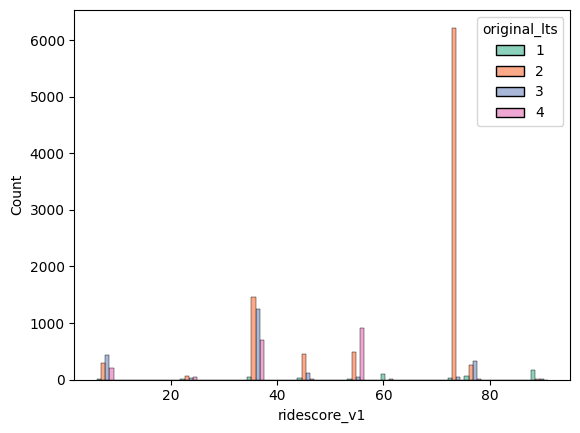

In [97]:
sns.histplot(data=roads_wRS, x="ridescore_v1", hue="original_lts", multiple = 'dodge', palette = 'Set2')